# 📈 Notebook 02c — Exponential Smoothing
**Goal:** Apply the family of exponential smoothing models — SES, Holt's Linear Trend, and Holt-Winters Seasonal — as stronger statistical baselines before moving to ARIMA/SARIMA.

## Models in this notebook

| Model | Trend | Seasonality | Notes |
|---|---|---|---|
| **SES** (Simple Exponential Smoothing) | ❌ | ❌ | Best for stationary series |
| **Holt's Linear Trend (DES)** | ✅ Linear | ❌ | Captures UPI's growth trend |
| **Holt-Winters Additive** | ✅ | ✅ Additive (s=7) | Seasonality has constant amplitude |
| **Holt-Winters Multiplicative** | ✅ | ✅ Multiplicative (s=7) | Seasonality grows with level — better for UPI |
| **ETS (Auto)** | Auto | Auto | statsmodels selects best error/trend/seasonal combo via AIC |

## Contents
1. Setup & Data
2. Simple Exponential Smoothing (SES)
3. Holt's Linear Trend (Double Exponential Smoothing)
4. Holt-Winters Additive (weekly s=7)
5. Holt-Winters Multiplicative (weekly s=7)
6. ETS Auto-selection
7. Side-by-side Forecast Plot
8. Metrics Table & Save


## 1. Setup & Data

In [1]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
warnings.filterwarnings("ignore")
os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

DATA_PATH  = "data/UPI_Master_2021_2026_Mar.csv"
TRAIN_END  = "2025-09-30"
TEST_START = "2025-10-01"
BLUE,RED,ORANGE,GREEN,PURPLE,BROWN,PINK,CYAN = (
    "#1A6FBF","#D62728","#E07B39","#2CA02C","#9467BD","#8C564B","#E377C2","#17BECF")

plt.rcParams.update({
    "figure.facecolor":"#FAFAFA","axes.facecolor":"#FAFAFA",
    "axes.grid":True,"grid.alpha":0.3,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False,
})

def evaluation_metrics(actual, predicted, model_name, target):
    a, p = np.array(actual), np.array(predicted)
    mask = ~np.isnan(p)
    a, p = a[mask], p[mask]
    return {
        "model":  model_name,
        "target": target,
        "MAE":    round(float(np.mean(np.abs(a-p))), 4),
        "RMSE":   round(float(np.sqrt(np.mean((a-p)**2))), 4),
        "MAPE":   round(float(np.mean(np.abs((a-p)/a))*100), 4),
    }

df    = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
train = df[df["Date"] <= TRAIN_END].copy()
test  = df[df["Date"] >= TEST_START].copy()
print(f"Train: {len(train):,}  |  Test: {len(test):,}")

results = {}


Train: 1,614  |  Test: 182


## 2. Simple Exponential Smoothing (SES)
> Weighted average of all past observations — more recent = higher weight.
> Best for flat, non-trending series. Will struggle with UPI's upward trend.

In [2]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_s = train.set_index("Date")[TARGET]
    actual  = test[TARGET].values

    model  = SimpleExpSmoothing(train_s, initialization_method="estimated")
    fitted = model.fit(optimized=True)
    alpha  = fitted.params["smoothing_level"]
    preds  = fitted.forecast(len(actual)).values

    m = evaluation_metrics(actual, preds, "SES", TARGET)
    results[f"SES|{TARGET}"] = m
    print(f"SES — {TARGET}  |  α={alpha:.4f}  |  MAE={m['MAE']:.2f}  MAPE={m['MAPE']:.2f}%")


SES — Volume (In Mn.)  |  α=0.6412  |  MAE=57.76  MAPE=8.26%
SES — Value (In Cr.)  |  α=0.4404  |  MAE=10333.99  MAPE=11.85%


## 3. Holt's Linear Trend (Double Exponential Smoothing)
> Adds a trend component to SES. Two smoothing parameters: α (level) and β (trend).
> Better for UPI's consistent upward growth.

In [3]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_s = train.set_index("Date")[TARGET]
    actual  = test[TARGET].values

    # Additive trend
    model_add  = ExponentialSmoothing(train_s, trend="add", seasonal=None,
                                      initialization_method="estimated")
    fitted_add = model_add.fit(optimized=True)
    preds_add  = fitted_add.forecast(len(actual)).values

    # Damped additive trend (prevents over-extrapolation)
    model_dmp  = ExponentialSmoothing(train_s, trend="add", damped_trend=True,
                                      seasonal=None, initialization_method="estimated")
    fitted_dmp = model_dmp.fit(optimized=True)
    preds_dmp  = fitted_dmp.forecast(len(actual)).values

    m_add = evaluation_metrics(actual, preds_add, "Holt Linear Trend",        TARGET)
    m_dmp = evaluation_metrics(actual, preds_dmp, "Holt Damped Trend",         TARGET)
    results[f"Holt Linear|{TARGET}"] = m_add
    results[f"Holt Damped|{TARGET}"] = m_dmp

    print(f"\n{TARGET}")
    print(f"  Holt Linear : MAE={m_add['MAE']:.2f}  MAPE={m_add['MAPE']:.2f}%")
    print(f"  Holt Damped : MAE={m_dmp['MAE']:.2f}  MAPE={m_dmp['MAPE']:.2f}%  ← usually better for longer horizons")



Volume (In Mn.)
  Holt Linear : MAE=48.28  MAPE=7.34%
  Holt Damped : MAE=57.76  MAPE=8.26%  ← usually better for longer horizons

Value (In Cr.)
  Holt Linear : MAE=9805.05  MAPE=11.81%
  Holt Damped : MAE=10334.30  MAPE=11.85%  ← usually better for longer horizons


## 4. Holt-Winters Additive (weekly seasonality, s=7)
> Three components: level (α), trend (β), seasonal (γ).
> Additive: seasonal fluctuations are constant regardless of the level.

In [4]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_s = train.set_index("Date")[TARGET]
    actual  = test[TARGET].values

    model  = ExponentialSmoothing(
        train_s,
        trend="add",
        seasonal="add",
        seasonal_periods=7,
        initialization_method="estimated",
    )
    fitted = model.fit(optimized=True)
    preds  = fitted.forecast(len(actual)).values

    p = fitted.params
    m = evaluation_metrics(actual, preds, "Holt-Winters Additive (s=7)", TARGET)
    results[f"HW Additive|{TARGET}"] = m
    print(f"Holt-Winters Additive — {TARGET}")
    print(f"  α={p['smoothing_level']:.4f}  β={p['smoothing_trend']:.4f}  γ={p['smoothing_seasonal']:.4f}")
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


Holt-Winters Additive — Volume (In Mn.)
  α=0.6619  β=0.0000  γ=0.0000
  MAE=47.74  RMSE=62.38  MAPE=7.28%
Holt-Winters Additive — Value (In Cr.)
  α=0.7936  β=0.0000  γ=0.0395
  MAE=10614.13  RMSE=13187.08  MAPE=12.82%


## 5. Holt-Winters Multiplicative (weekly seasonality, s=7)
> Seasonal fluctuations scale with the level — as UPI volume grows, so do the weekend dips.
> **Usually the best Holt-Winters variant for UPI** because of the strong growth trend.

In [5]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_s = train.set_index("Date")[TARGET]
    actual  = test[TARGET].values

    model  = ExponentialSmoothing(
        train_s,
        trend="add",
        seasonal="mul",          # multiplicative seasonality
        seasonal_periods=7,
        initialization_method="estimated",
    )
    fitted = model.fit(optimized=True)
    preds  = fitted.forecast(len(actual)).values

    p = fitted.params
    m = evaluation_metrics(actual, preds, "Holt-Winters Multiplicative (s=7)", TARGET)
    results[f"HW Multiplicative|{TARGET}"] = m
    print(f"Holt-Winters Multiplicative — {TARGET}")
    print(f"  α={p['smoothing_level']:.4f}  β={p['smoothing_trend']:.4f}  γ={p['smoothing_seasonal']:.4f}")
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


Holt-Winters Multiplicative — Volume (In Mn.)
  α=0.6470  β=0.0000  γ=0.0336
  MAE=48.38  RMSE=62.55  MAPE=7.35%
Holt-Winters Multiplicative — Value (In Cr.)
  α=0.8421  β=0.0014  γ=0.0000
  MAE=9326.92  RMSE=12255.37  MAPE=11.24%


## 6. ETS — Automatic Error/Trend/Seasonal Selection
> ETS systematically tries all combinations of error type (A/M), trend (N/A/Ad), and seasonal (N/A/M) and picks the best by AIC.
> Think of it as the exponential smoothing equivalent of `auto_arima`.

In [6]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_s = train.set_index("Date")[TARGET]
    actual  = test[TARGET].values

    print(f"\nFitting ETS (auto) — {TARGET}...")
    ets_model  = ETSModel(
        train_s,
        error="mul",        # multiplicative error fits growing series
        trend="add",
        seasonal="mul",
        seasonal_periods=7,
        initialization_method="estimated",
    )
    ets_fitted = ets_model.fit(disp=False)
    preds      = ets_fitted.forecast(len(actual)).values

    print(ets_fitted.summary())
    m = evaluation_metrics(actual, preds, "ETS (mul,add,mul,7)", TARGET)
    results[f"ETS Auto|{TARGET}"] = m
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")



Fitting ETS (auto) — Volume (In Mn.)...
                                 ETS Results                                  
Dep. Variable:        Volume (In Mn.)   No. Observations:                 1614
Model:                       ETS(MAM)   Log Likelihood               -6059.828
Date:                Sat, 18 Apr 2026   AIC                          12145.657
Time:                        21:56:19   BIC                          12215.681
Sample:                    05-01-2021   HQIC                         12171.647
                         - 09-30-2025   Scale                            0.001
Covariance Type:               approx                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
smoothing_level        0.6749      0.025     26.989      0.000       0.626       0.724
smoothing_trend     6.749e-05        nan        nan        nan    

## 7. Side-by-Side Forecast Plot

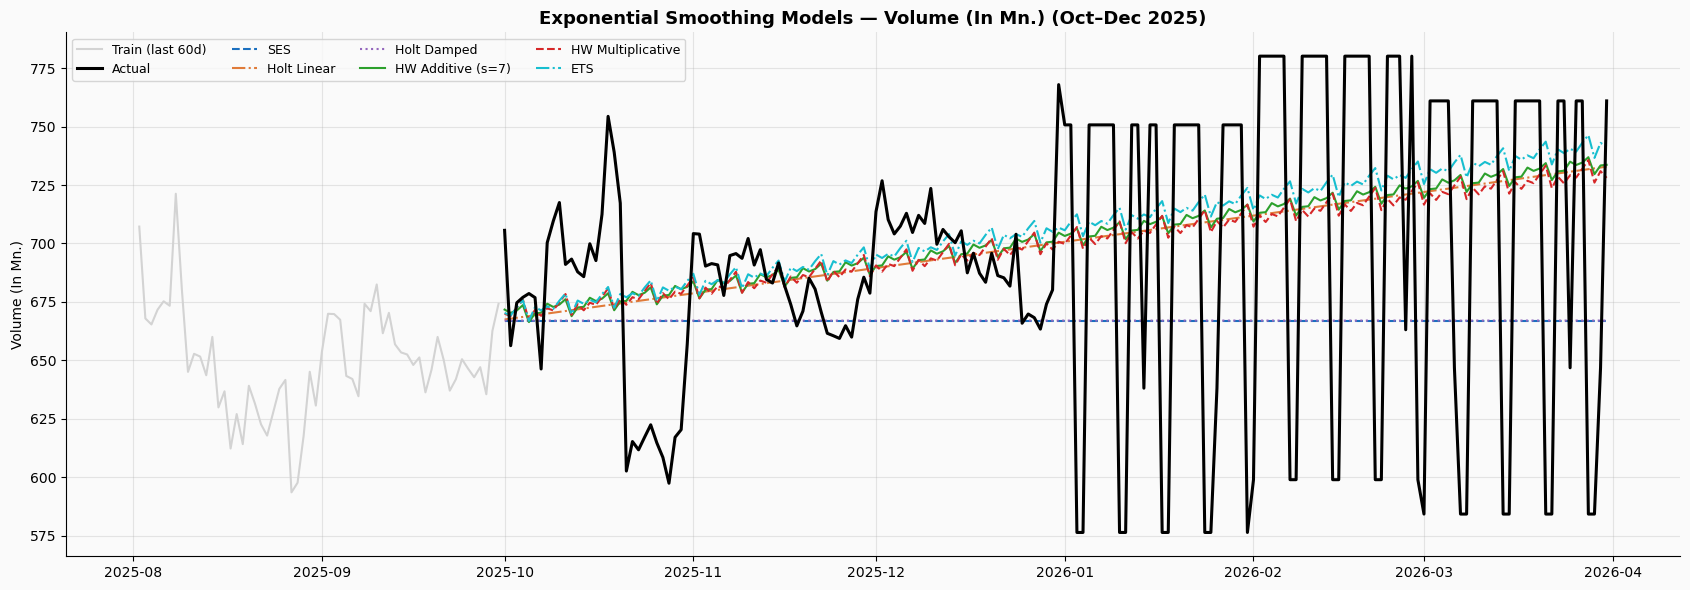

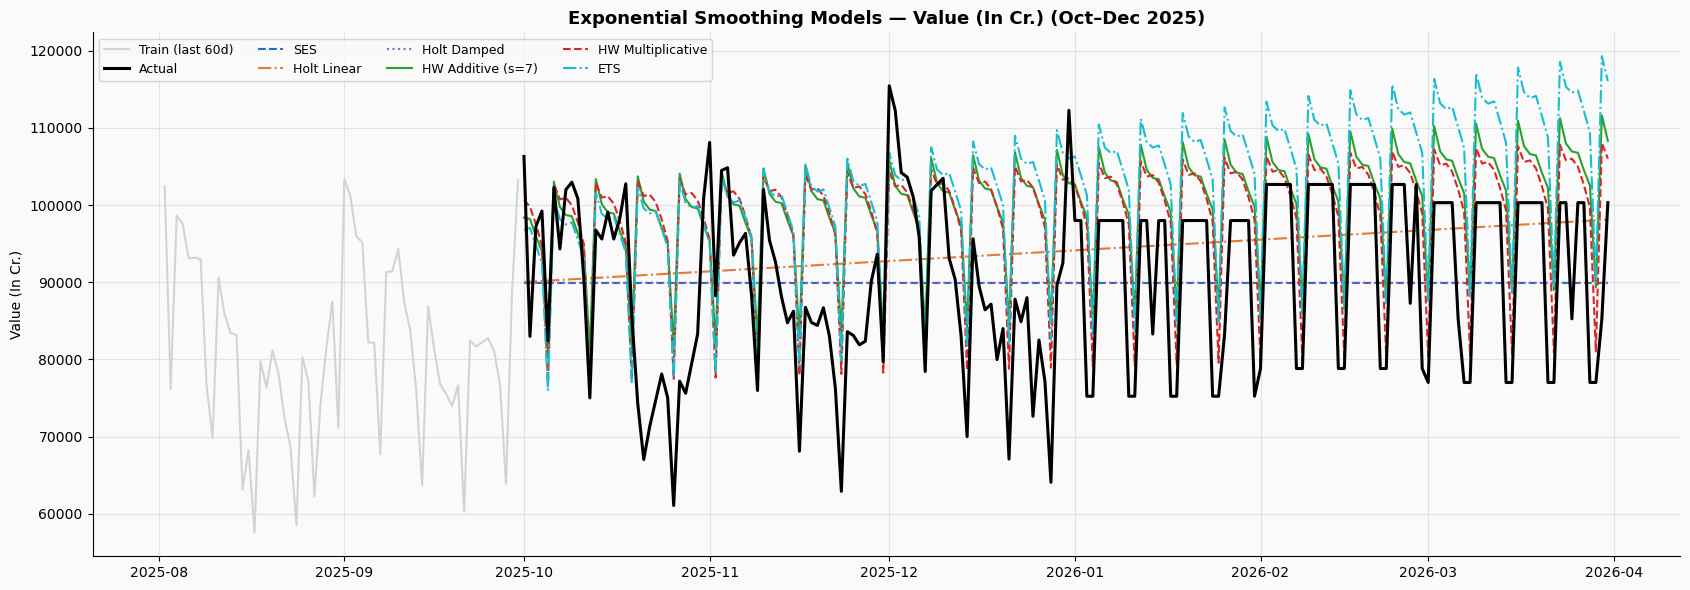

In [7]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_s = train.set_index("Date")[TARGET]
    actual  = test[TARGET].values
    test_dates = test["Date"].values

    # Re-generate all forecasts for plotting
    def hw_forecast(trend, seasonal, damped=False):
        kw = dict(trend=trend, seasonal=seasonal, initialization_method="estimated")
        if seasonal: kw["seasonal_periods"] = 7
        if damped:   kw["damped_trend"] = True
        return ExponentialSmoothing(train_s, **kw).fit(optimized=True).forecast(len(actual)).values

    forecasts = {
        "SES":                SimpleExpSmoothing(train_s, initialization_method="estimated").fit(optimized=True).forecast(len(actual)).values,
        "Holt Linear":        hw_forecast("add", None),
        "Holt Damped":        hw_forecast("add", None, damped=True),
        "HW Additive (s=7)":  hw_forecast("add", "add"),
        "HW Multiplicative":  hw_forecast("add", "mul"),
        "ETS":                ETSModel(train_s,error="mul",trend="add",seasonal="mul",seasonal_periods=7,initialization_method="estimated").fit(disp=False).forecast(len(actual)).values,
    }
    line_styles = ["--","-.",":","-","--","-."]
    colors_list = [BLUE,ORANGE,PURPLE,GREEN,RED,CYAN]

    fig, ax = plt.subplots(figsize=(17, 6))
    ax.plot(train["Date"].values[-60:], train_s.values[-60:],
            color="lightgray", lw=1.5, label="Train (last 60d)")
    ax.plot(test_dates, actual, color="black", lw=2.2, label="Actual", zorder=10)

    for (name, preds), ls, col in zip(forecasts.items(), line_styles, colors_list):
        ax.plot(test_dates, preds, color=col, lw=1.5, linestyle=ls, label=name)

    ax.set_title(f"Exponential Smoothing Models — {TARGET} (Oct–Dec 2025)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel(TARGET)
    ax.legend(ncol=4, fontsize=9, loc="upper left")
    plt.tight_layout()
    plt.savefig(f"plots/02c_exp_smoothing_{TARGET[:3].lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 8. Metrics Table & Save

In [8]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    rows = [v for k,v in results.items() if TARGET in k]
    df_res = pd.DataFrame(rows).sort_values("MAPE").reset_index(drop=True)
    df_res.index += 1
    print(f"\n{'='*60}\n  Exponential Smoothing — {TARGET}\n{'='*60}")
    print(df_res[["model","MAE","RMSE","MAPE"]].to_string())
    print(f"\n  ★ Best: {df_res.iloc[0]['model']}  MAPE={df_res.iloc[0]['MAPE']:.2f}%")

# Save metrics
saved = []
for key, m in results.items():
    fname = f"models/expsmooth_{m['model'].lower().replace(' ','_').replace('(','').replace(')','').replace('=','').replace(',','_')}_{m['target'][:3].lower()}_metrics.json"
    with open(fname, "w") as f:
        json.dump(m, f, indent=2)
    saved.append(fname)
print(f"\n✅ {len(saved)} metric files saved to models/")



  Exponential Smoothing — Volume (In Mn.)
                               model      MAE     RMSE    MAPE
1                ETS (mul,add,mul,7)  47.1228  63.5855  7.2476
2        Holt-Winters Additive (s=7)  47.7433  62.3776  7.2809
3                  Holt Linear Trend  48.2837  62.3826  7.3387
4  Holt-Winters Multiplicative (s=7)  48.3762  62.5452  7.3487
5                                SES  57.7570  67.9734  8.2599
6                  Holt Damped Trend  57.7579  67.9729  8.2600

  ★ Best: ETS (mul,add,mul,7)  MAPE=7.25%

  Exponential Smoothing — Value (In Cr.)
                               model         MAE        RMSE     MAPE
1  Holt-Winters Multiplicative (s=7)   9326.9192  12255.3712  11.2400
2                  Holt Linear Trend   9805.0530  12005.7223  11.8064
3                  Holt Damped Trend  10334.3042  11556.0379  11.8516
4                                SES  10333.9896  11555.8853  11.8518
5        Holt-Winters Additive (s=7)  10614.1275  13187.0822  12.8190
6          